<a href="https://colab.research.google.com/github/RECTY45/learning-decision-support-system/blob/main/consine_similarity_retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.1 MB/s eta 0:00:00


In [1]:
document = {

    "d1": "Dosen-dosen Unitama sedang melaksanakan rapat koordinasi dosen di aula kampus Unitama.",
    "d2": "Pasnur merupakan salah seorang dosen di kampus Unitama Makassar.",
    "d3": "Bagaimana keakraban dosen-dosen dan mahasiswa-mahasiswa di kampus Unitama?",
    "d4": "Kota Makassar merupakan kota terbesar di Sulawesi Selatan dan dicanangkan sebagai kota dunia.",
    "d5": "Saya merasa mata kuliah sistem temu kembali informasi cukup menarik untuk dipelajari, dan saya berharap disini saya mendapatkan ilmu yang banyak karena saya suka sekali dengan STKI (sistem temu kembali).",
    "d6" : "Nama saya Fery Fadul Rahman, saya memiliki hobi bermain gitar serta senang mempelajari berbagai hal baru terutama di bidang pemrograman.",
    "q"  : "Dosen Unitama Makassar"
}

In [3]:
import pandas as pd

df = pd.DataFrame(list(document.items()), columns=["document_id", "document_contents"])
df

,document_id,document_contents
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...
4,d5,Saya merasa mata kuliah sistem temu kembali in...
5,d6,"Nama saya Fery Fadul Rahman, saya memiliki hob..."
6,q,Dosen Unitama Makassar


In [4]:
def case_folding(text):
  return text.lower()

In [5]:
df["contents_casefolding"] = df["document_contents"].apply(case_folding)
df

,document_id,document_contents,contents_casefolding
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...
4,d5,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...
5,d6,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob..."
6,q,Dosen Unitama Makassar,dosen unitama makassar


In [7]:
import re

def filtering(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [8]:
df['contents_filtering'] = df["contents_casefolding"].apply(filtering)
df

,document_id,document_contents,contents_casefolding,contents_filtering
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen dosen dan mahasiswa ...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar di sulaw...
4,d5,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...
5,d6,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob...",nama saya fery fadul rahman saya memiliki hobi...
6,q,Dosen Unitama Makassar,dosen unitama makassar,dosen unitama makassar


In [9]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def remove_stopword(text) :
  return stopword_remover.remove(text)

In [10]:
df["contents_stopword"] = df["contents_filtering"].apply(remove_stopword)
df

,document_id,document_contents,contents_casefolding,contents_filtering,contents_stopword
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen kampus un...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen dosen dan mahasiswa ...,bagaimana keakraban dosen dosen mahasiswa maha...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar sulawesi...
4,d5,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,merasa mata kuliah sistem temu informasi cukup...
5,d6,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob...",nama saya fery fadul rahman saya memiliki hobi...,nama fery fadul rahman memiliki hobi bermain g...
6,q,Dosen Unitama Makassar,dosen unitama makassar,dosen unitama makassar,dosen unitama makassar


In [11]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

def stemming(text):
  return stemmer.stem(text)

In [12]:
df["contents_stemming"] = df["contents_stopword"].apply(stemming)
df

,document_id,document_contents,contents_casefolding,contents_filtering,contents_stopword,contents_stemming
0,d1,Dosen-dosen Unitama sedang melaksanakan rapat ...,dosen-dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang melaksanakan rapat ...,dosen dosen unitama sedang laksana rapat koord...
1,d2,Pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen di kampus...,pasnur merupakan salah seorang dosen kampus un...,pasnur rupa salah orang dosen kampus unitama m...
2,d3,Bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen-dosen dan mahasiswa-...,bagaimana keakraban dosen dosen dan mahasiswa ...,bagaimana keakraban dosen dosen mahasiswa maha...,bagaimana akrab dosen dosen mahasiswa mahasisw...
3,d4,Kota Makassar merupakan kota terbesar di Sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar di sulaw...,kota makassar merupakan kota terbesar sulawesi...,kota makassar rupa kota besar sulawesi selatan...
4,d5,Saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,saya merasa mata kuliah sistem temu kembali in...,merasa mata kuliah sistem temu informasi cukup...,rasa mata kuliah sistem temu informasi cukup t...
5,d6,"Nama saya Fery Fadul Rahman, saya memiliki hob...","nama saya fery fadul rahman, saya memiliki hob...",nama saya fery fadul rahman saya memiliki hobi...,nama fery fadul rahman memiliki hobi bermain g...,nama fery fadul rahman milik hobi main gitar s...
6,q,Dosen Unitama Makassar,dosen unitama makassar,dosen unitama makassar,dosen unitama makassar,dosen unitama makassar


In [13]:
df_clean = df[["document_id", "contents_stemming"]].copy()
df_clean.columns = ["document_id", "document_contents"]
df_clean

,document_id,document_contents
0,d1,dosen dosen unitama sedang laksana rapat koord...
1,d2,pasnur rupa salah orang dosen kampus unitama m...
2,d3,bagaimana akrab dosen dosen mahasiswa mahasisw...
3,d4,kota makassar rupa kota besar sulawesi selatan...
4,d5,rasa mata kuliah sistem temu informasi cukup t...
5,d6,nama fery fadul rahman milik hobi main gitar s...
6,q,dosen unitama makassar


In [22]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_clean["document_contents"])

tf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df_clean["document_id"]
)

tf_transpose = tf_df.T

tf_transpose.reset_index(inplace=True)
tf_transpose.rename(columns={"index": "Term/Kata"}, inplace=True)

tf_transpose

document_id,Term/Kata,d1,d2,d3,d4,d5,d6,q
0,ajar,0,0,0,0,1,1,0
1,akrab,0,0,1,0,0,0,0
2,aula,1,0,0,0,0,0,0
3,bagai,0,0,0,0,0,1,0
4,bagaimana,0,0,1,0,0,0,0
5,banyak,0,0,0,0,1,0,0
6,baru,0,0,0,0,0,1,0
7,besar,0,0,0,1,0,0,0
8,bidang,0,0,0,0,0,1,0
9,canang,0,0,0,1,0,0,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer(
    use_idf=True,
    smooth_idf=True,
    sublinear_tf=False,
    norm=None
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean["document_contents"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df.insert(0, "document_id", df_clean["document_id"])

tfidf_df

In [23]:
import numpy as np

query_vec = tfidf_df[tfidf_df["document_id"] == "q"].drop(columns=["document_id"]).values[0]

hasil = []

for i, row in tfidf_df.iterrows():
    if row["document_id"] == "q":
        continue

    doc_vec = row.drop("document_id").values

    dot = np.dot(query_vec, doc_vec)
    norm_q = np.linalg.norm(query_vec)
    norm_d = np.linalg.norm(doc_vec)

    sim = dot / (norm_q * norm_d)

    hasil.append((row["document_id"], sim))

sim_df = pd.DataFrame(hasil, columns=["document_id", "cosine_similarity"])
sim_df = sim_df.sort_values(by="cosine_similarity", ascending=False)

sim_df

,document_id,cosine_similarity
0,d1,0.522734
1,d2,0.481066
2,d3,0.349584
3,d4,0.114956
4,d5,0.000000
5,d6,0.000000


In [26]:
threshold = 0.2

In [27]:
import matplotlib.pyplot as plt

relevansi = {
    "d1": 1, "d2": 1, "d3": 1,
    "d4": 0, "d5": 0, "d6": 0
}


In [28]:
TP = len(sim_df[(sim_df.prediksi == 1) & (sim_df.aktual == 1)])
FP = len(sim_df[(sim_df.prediksi == 1) & (sim_df.aktual == 0)])
FN = len(sim_df[(sim_df.prediksi == 0) & (sim_df.aktual == 1)])
TN = len(sim_df[(sim_df.prediksi == 0) & (sim_df.aktual == 0)])

cm = [[TP, FP],
      [FN, TN]]

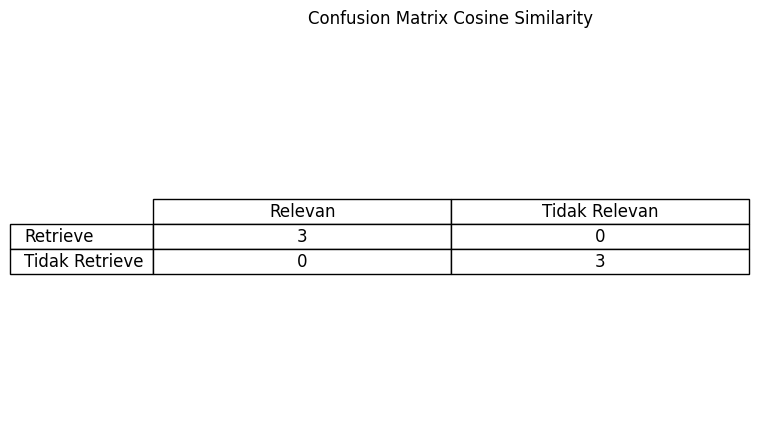

In [41]:
cm_df = pd.DataFrame(
    cm,
    index=["Retrieve", "Tidak Retrieve"],
    columns=["Relevan", "Tidak Relevan"]
)

fig, ax = plt.subplots()
ax.axis("off")

table = ax.table(
    cellText=cm_df.values,
    rowLabels=cm_df.index,
    colLabels=cm_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

plt.title("Confusion Matrix Cosine Similarity", pad=20)
plt.show()

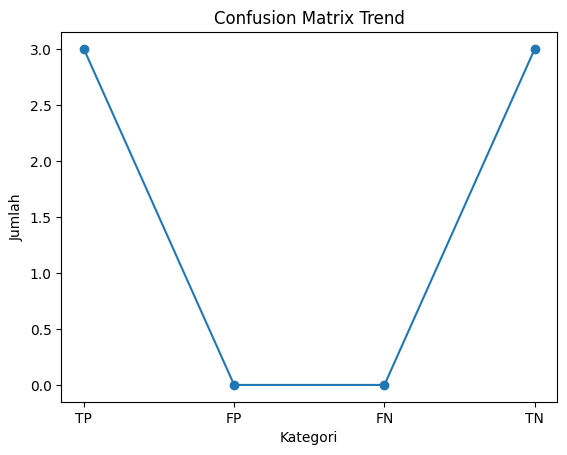

In [40]:
labels = ["TP", "FP", "FN", "TN"]
values = [TP, FP, FN, TN]

plt.figure()
plt.plot(labels, values, marker='o')
plt.title("Confusion Matrix")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.show()

In [42]:
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) != 0 else 0
accuracy = (TP + TN) / (TP + FP + FN + TN)

print("=== HASIL EVALUASI ===")
print(f"TP : {TP}")
print(f"FP : {FP}")
print(f"FN : {FN}")
print(f"TN : {TN}")
print("----------------------")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1_score:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print("----------------------")

=== HASIL EVALUASI ===
TP : 3
FP : 0
FN : 0
TN : 3
----------------------
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
Accuracy  : 1.0000
----------------------
